# Welcome!
This is the notebook of our project **Implementing Deutsch and Deutsch-Jozsa Algorithm for 2- and 3- and 4-Qubit Systems**, from Amariah Brathwaite, Dhakshan Balaramesh and Cristian Echeverri.

For our *poster*, *paper* and *GitHub Repo*, you can go to this landing page.

[https://bit.ly/m/bloch-heads](https://bit.ly/m/bloch-heads)





First, let's see whether your Colab works. Please check if you see the message `'Deutsch!'`

In [ ]:
def deutschhhh(case: int):
  if type(case) == int:
    print('Deutsch!')

deutschhhh(684)

Deutsch!


We'll now go into installing and importing necessary packages.


# Install and import necessary packages

Please upload into the Notebook folder the `qubit_manipulation_requirements.txt` from the [GitHub Repo]()



### Install necessary packages

In [ ]:
# Installing the necessary packages from the requirements file.

!pip install -r /content/qubit_manipulation_requirements.txt

print("Imported succesfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━

### Getting the Qiskit Runtime service and importing libraries

In [ ]:
# Import the Qiskit Runtime Service and the Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Get the account and the channel
QiskitRuntimeService.save_account(channel = 'ibm_quantum_platform', instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/64c8cf49310b4a63bb81d67d5fe7e171:31d779b5-cf75-4a3a-976b-dce62da573ef::', token='DP5uJkMhsTc3t83gpD90rT7qyqPIKImfLmdplw324aya', overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel = 'ibm_quantum_platform')

#Call the Runtime Service
service = QiskitRuntimeService()

# Use a determined backend for our Algorithm Implementation
backend = service.backend("ibm_marrakesh")
print(backend.name)

sampler = Sampler(mode = backend)

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


ibm_marrakesh


In [ ]:
# Import a Noise Model to be more realistic

from qiskit.primitives import BackendSamplerV2


from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

backend_sim = AerSimulator(noise_model = noise_model)
sampler_sim = BackendSamplerV2(backend = backend_sim)

## Importing necessary libraries

In [ ]:
# These libraries will be very helpful at all stages of the project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile
from collections import Counter

# Oracles

Oracles are functions that are embeeded into a Quantum Circuit, they are not only used in Deutsch and Deutsch-Jozsa Algorithms but in an important set of different Algorithms.

In Deutsch's Algorithm problem set, the oracle $U_f$ performs the transformation:
$|x\rangle|y\rangle →|x\rangle|y\oplus f(x)\rangle$

Where $\oplus$ denotes XOR (addition modulo 2).



We'll work with functions of the form $\{0,1\}^n → \{0,1\}$, being $n$ a natural number. Taking in this project only the ones for $n=1$ and $n=2$, we'll define two type of functions:

*   **Balanced:** Half inputs are 0s and half inputs are 1s.
*   **Constant:** All inputs are either 0s and 1s.

The goal of the Algorithm proposed [4][5] is to guess whether this function is constant or balanced with a single query, using, for the sake of efficiency, quantum superposition.

###Implementing the Oracles of the function $\{0,1\} → \{0,1\}$

---



We'll have 4 functions, two of them are constant and two of them are balanced.

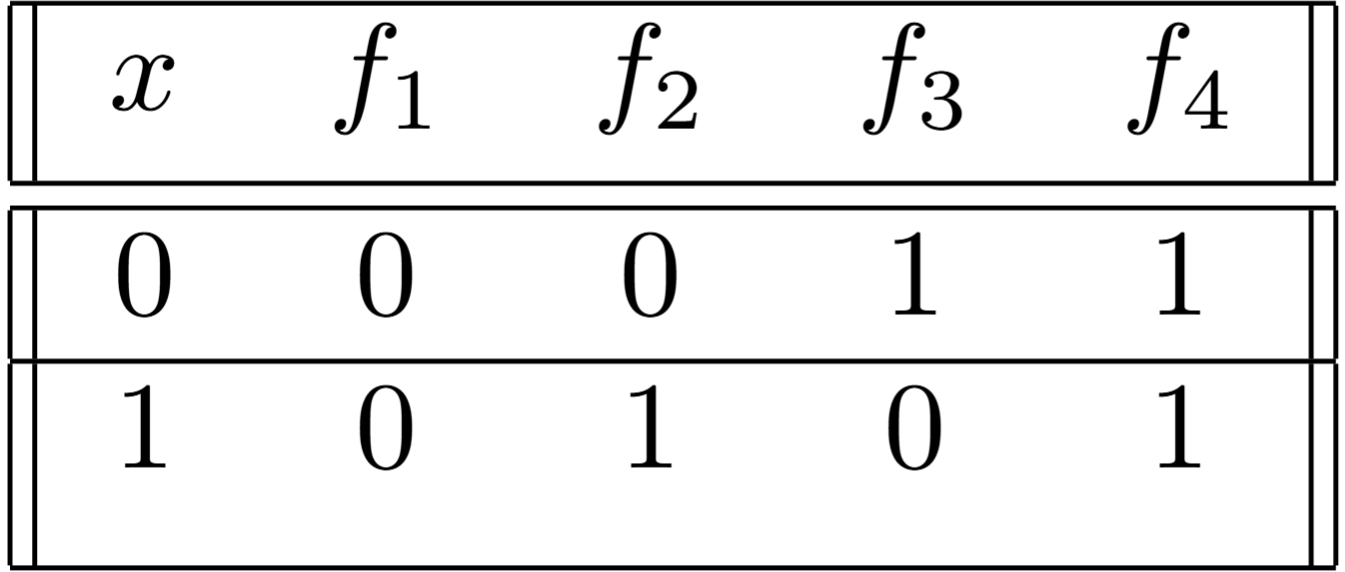

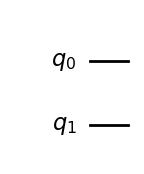

In [ ]:
# Function 1: 0 Function

d1 = QuantumCircuit(2)

d1.draw('mpl')

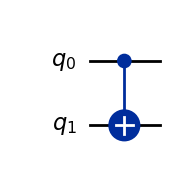

In [ ]:
# Function 2: Identity Function

d2 = QuantumCircuit(2)
d2.cx(0, 1)

d2.draw('mpl')

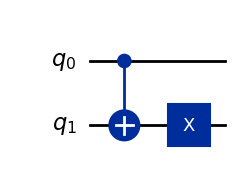

In [ ]:
# Function 3: NOT Function

d3 = QuantumCircuit(2)
d3.cx(0, 1)
d3.x(1)

d3.draw('mpl')

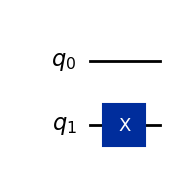

In [ ]:
# Function 4: 1 Function

d4 = QuantumCircuit(2)
d4.x(1)

d4.draw('mpl')

### Implementing the Oracles of the function $\{0,1\}^2 → \{0,1\}$

We'll have 8 functions. Two of them are constant and six of them are balanced. As shown in the table below.


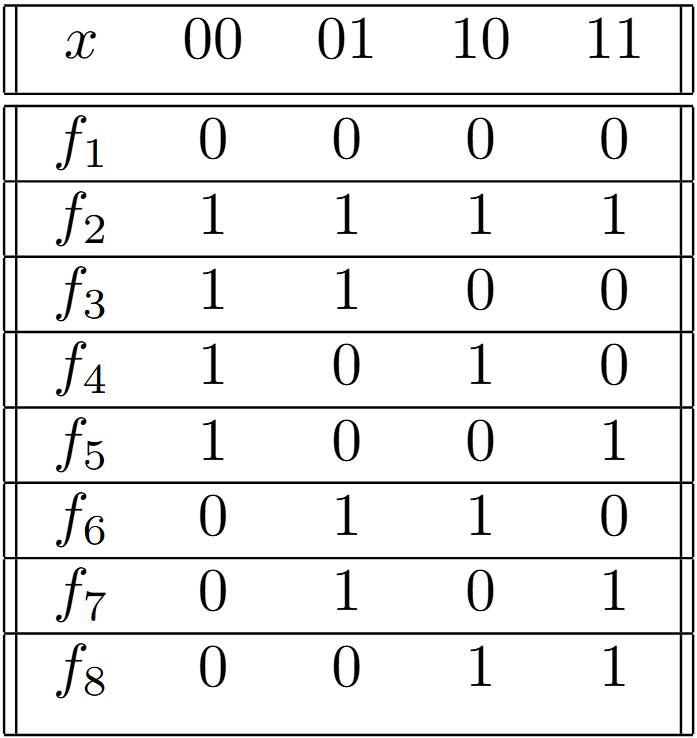

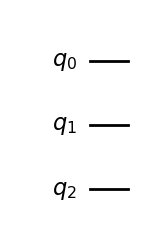

In [ ]:
# First Function

dj1 = QuantumCircuit(3)

dj1.draw('mpl')

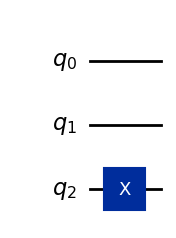

In [ ]:
# Second

dj2 = QuantumCircuit(3)
dj2.x(2)

dj2.draw('mpl')

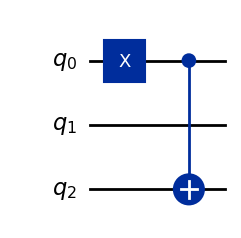

In [ ]:
# Third Function

dj3 = QuantumCircuit(3)
dj3.x(0)
dj3.cx(0, 2)

dj3.draw('mpl')

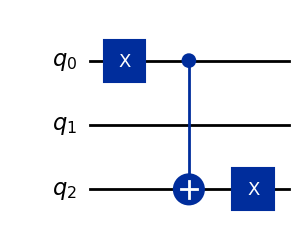

In [ ]:
# Fourth Function

dj4 = QuantumCircuit(3)

dj4.x(0)
dj4.cx(0, 2)
dj4.x(2)

dj4.draw('mpl')

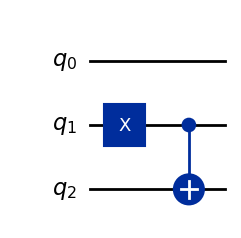

In [ ]:
# Fifth Function

dj5 = QuantumCircuit(3)
dj5.x(1)
dj5.cx(1, 2)

dj5.draw('mpl')

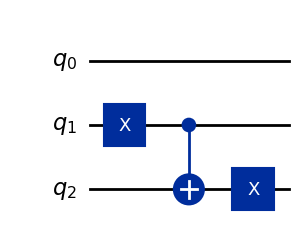

In [ ]:
# Sixth Function

dj6 = QuantumCircuit(3)

dj6.x(1)
dj6.cx(1, 2)
dj6.x(2)

dj6.draw('mpl')

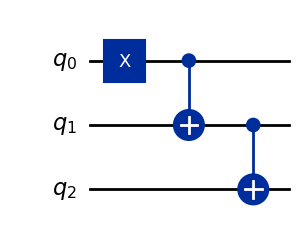

In [ ]:
# Seventh Function

dj7 = QuantumCircuit(3)
dj7.x(0)
dj7.cx(0, 1)
dj7.cx(1, 2)

dj7.draw('mpl')

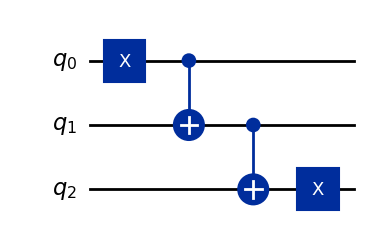

In [ ]:
# Eighth Function

dj8 = QuantumCircuit(3)

dj8 = QuantumCircuit(3)
dj8.x(0)
dj8.cx(0, 1)
dj8.cx(1, 2)
dj8.x(2)

dj8.draw('mpl')

# Deutsch Algorithm

The purpose of Deutsch Algorithm is to predict whether a certain function of the form $\{0, 1\} \rightarrow \{0, 1\}$ is balanced or constant.

### Important Problem!

With the previous definition of oracles, a problem becomes clear: if we already know the oracle, what is the sense of implementing an algorithm that tries to guess it?

The initial purpose of Deutsch (and further Deutsch-Jozsa Algorithm) is to demonstrate that quantum computers can, indeed, surpass classical computers in terms of efficiency. Deutsch Algorithm didn't appear as a solution to a practical problem but to prove different speculations of scientists at the time.

## Starting of Deutsch Algorithm

As we have shown before, the functions of the type  can be solved (or guessed) differently, which show, however, less advantage than Deutsch Algorithm.

### Approaching Algorithm

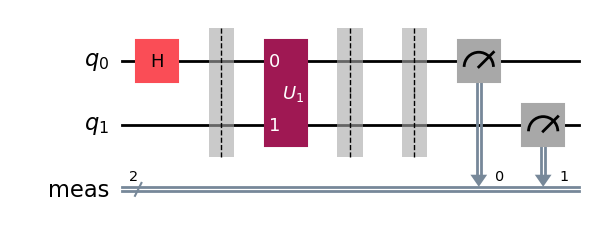

In [ ]:
# Let's take the second oracle of the functions
qc_1 = QuantumCircuit(2)

oracle_1 = d2.to_gate()
oracle_1.label = "$U_1$"

qc_1.h(0)
qc_1.barrier()
qc_1.compose(oracle_1, inplace=True)
qc_1.barrier()
qc_1.measure_all()

qc_1.draw('mpl')

In [ ]:
# Step 2: Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa_1 = pm.run(qc_1)

In [ ]:
# Step 3: Run the job on a real (or simulated) quantum computer

job = sampler.run([qc_isa_1], shots = 1)
res = job.result()
counts = res[0].data.meas.get_counts()

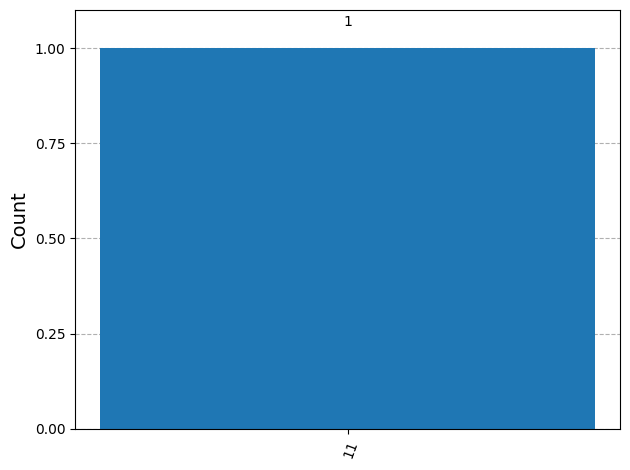

In [ ]:
plot_histogram(counts)

It's woth noting the "little endian" notation that works in Qiskit. The last number is the input and the first number is the output of the function. For an only shot, we get a `00`. This means that as the input was 0, the output was 1. However, we still don't know if the function is constant or balanced. With the best of luck we'll get the information with two queries.



In [ ]:
# Choose a random number of shots

s = 2

In [ ]:
# Step 3 (again): Run the job on a real (or simulated) quantum computer

job = sampler.run([qc_isa_1], shots = s)
res = job.result()
counts = res[0].data.meas.get_counts()

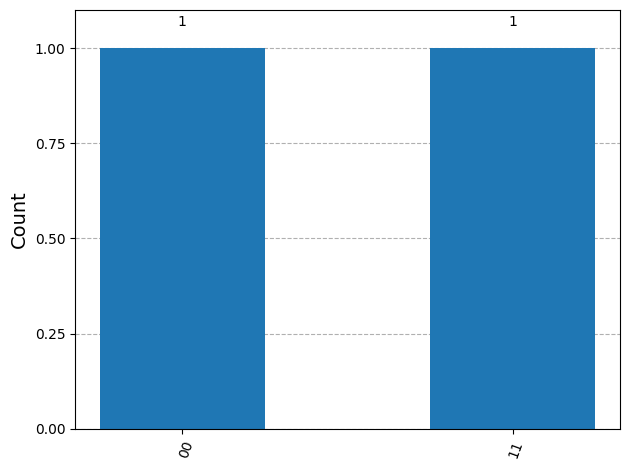

In [ ]:
plot_histogram(counts)

With only 2 shots, we got lucky to know that the function is a constant function! Play with the algorithm! Choose the oracle you want to apply and a random (choose big numbers) number of shots.

#### Noise in the Approaching Algorithm

If we tend to implement big numbers, we'll see the Noise effect that is present in the IBM Quantum Computer. This will be most useful in our project.

In [ ]:
big_number = 300

job = sampler.run([qc_isa_1], shots = big_number)
res = job.result()
counts = res[0].data.meas.get_counts()

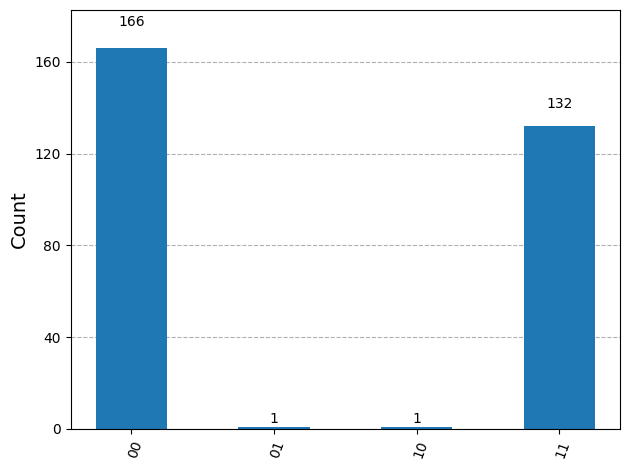

In [ ]:
plot_histogram(counts)

See that there are still some discrepancies in the measurements caused by noise in the IBM Quantum Computer, outputting `01` and `10` in some cases.

## Formal Deutsch Algorithm

Here we expose the formal Deutsch Algorithm based in the [Qiskit textbook](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)

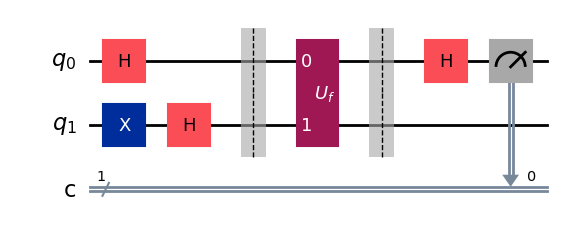

In [ ]:
# Let's try now with the third oracle

blackbox = d3.to_gate()
blackbox.label = "$U_f$"

# Defining the Quantum Circuit
qc_deutsch = QuantumCircuit(2, 1)

qc_deutsch.x(1)
qc_deutsch.h(range(2))

qc_deutsch.barrier()

qc_deutsch.compose(blackbox, inplace = True)

qc_deutsch.barrier()

qc_deutsch.h(0)

qc_deutsch.measure(0, 0)

qc_deutsch.draw('mpl')

In [ ]:
# Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_deutsch)

In [ ]:
# Define a number of shots

shots = 30

In [ ]:
# Step 3: Run the job on a real quantum computer

job = sampler.run([qc_isa], shots = shots)
res = job.result()
counts = res[0].data.c.get_counts()

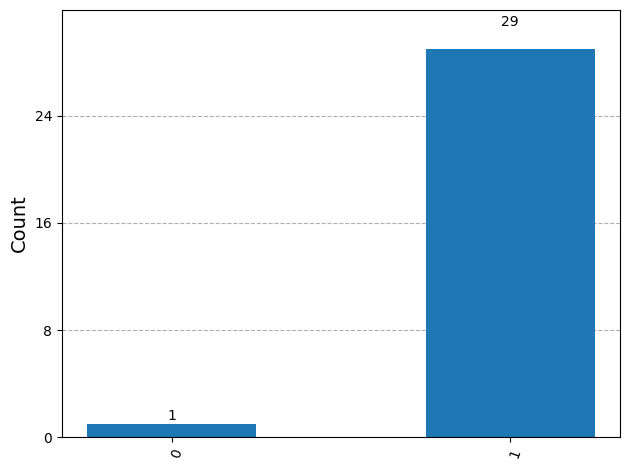

In [ ]:
plot_histogram(counts)

This algorithm showed, with a single query, that the third function is balanced. It poses the problem, however, that we cannot guess the complete function but only a characteristic from it.

## Data Extraction

The Noise Model we used was based on the `'ibm_fez'` backend service. With this, we test how many times the four types of functions are displayed as constant or balanced. We then average the results of 1000 trials.

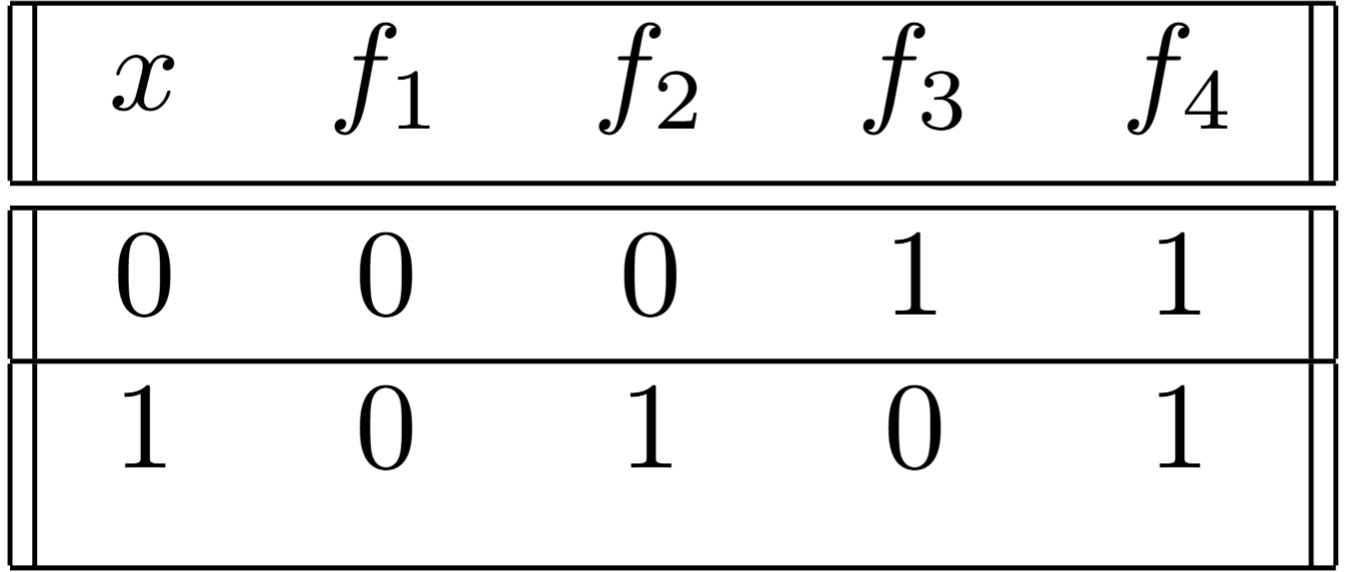

In [ ]:
# Creation of generic function to create a Quantum Circuit

def quantum_circuit(gate):
  # Defining the Quantum Circuit
  qc_deutsch = QuantumCircuit(2, 1)

  qc_deutsch.x(1)
  qc_deutsch.h(range(2))

  qc_deutsch.barrier()

  qc_deutsch.compose(gate, inplace = True)

  qc_deutsch.barrier()

  qc_deutsch.h(0)

  qc_deutsch.measure(0, 0)

  return qc_deutsch

In [ ]:
# Define a number of shots. For our study we use 100

number_shots = 1000

In [ ]:
# Function that converts each output number from the Deutsch Algorithm to the category of 'constant' and 'balanced'

def dictionary_to_decision(dictionary):
    list_numbers = []
    for i in dictionary:
      for j in range(counts[i]):
        list_numbers.append(i)
  #####################################################
    decision = []
    for i in list_numbers:
      if '1' in i:
        decision.append('balanced')
      else:
        decision.append('constant')
    return Counter(decision)

### $f_1$

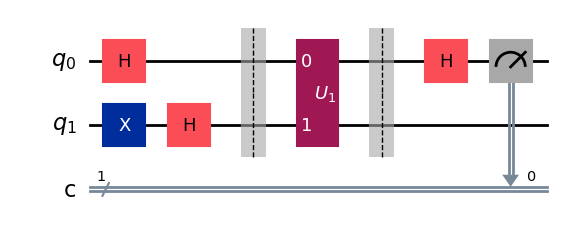

In [ ]:
f_1 = d1.to_gate()
f_1.label = "$U_1$"

circ_1 = quantum_circuit(f_1)

circ_1.draw('mpl')

In [ ]:
# Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circ_1 = pm.run(circ_1)

# Run the job on a real quantum computer

job = sampler.run([circ_1], shots = number_shots)
#job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()
counts_d1 = dictionary_to_decision(counts)

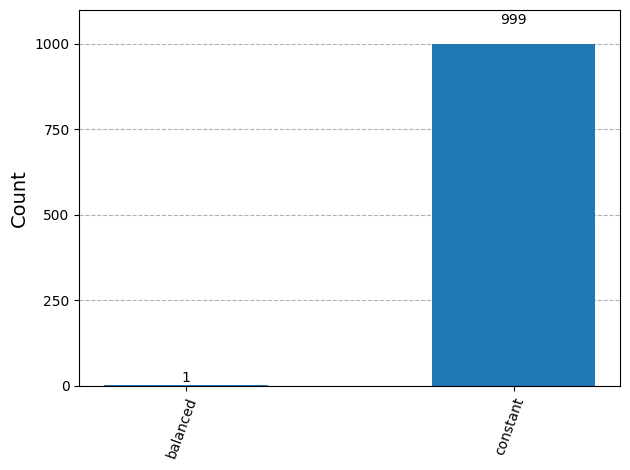

In [ ]:
plot_histogram(counts_d1)

#### $f_1$ in Aer Simulator

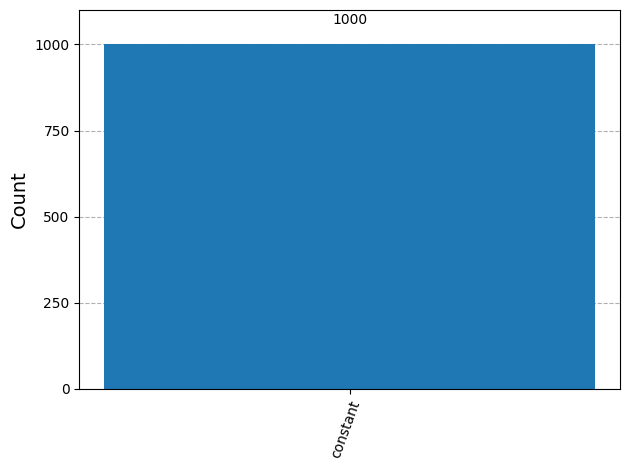

In [ ]:
circ_1 = quantum_circuit(f_1)

circ_1.draw('mpl')

sim = Aer.get_backend('qasm_simulator')
circ_1 = transpile(circ_1, sim)
result = sim.run(circ_1, shots = 1000).result()
counts = result.get_counts(circ_1)
counts_ds1 = dictionary_to_decision(counts)

plot_histogram(counts_ds1)

### $f_2$

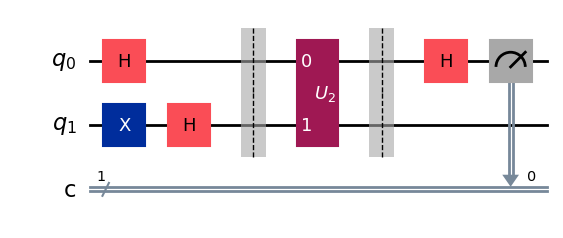

In [ ]:
f_2 = d2.to_gate()
f_2.label = "$U_2$"

circ_2 = quantum_circuit(f_2)

circ_2.draw('mpl')

In [ ]:
# Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circ_2 = pm.run(circ_2)

# Run the job on a real quantum computer

job = sampler.run([circ_2], shots = number_shots)
res = job.result()
counts = res[0].data.c.get_counts()
counts_d2 = dictionary_to_decision(counts)

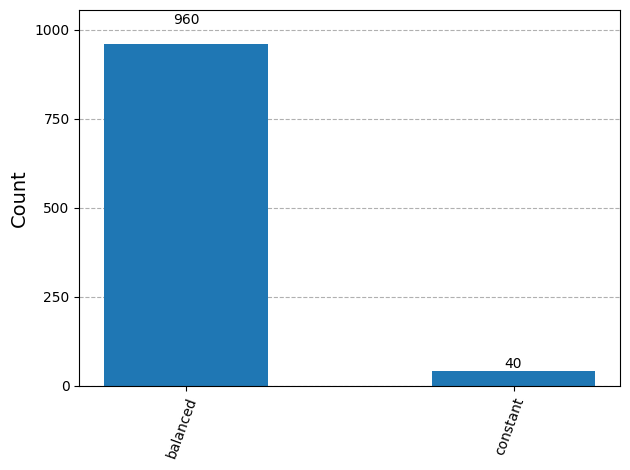

In [ ]:
plot_histogram(counts_d2)

#### $f_2$ in the Aer Simulator

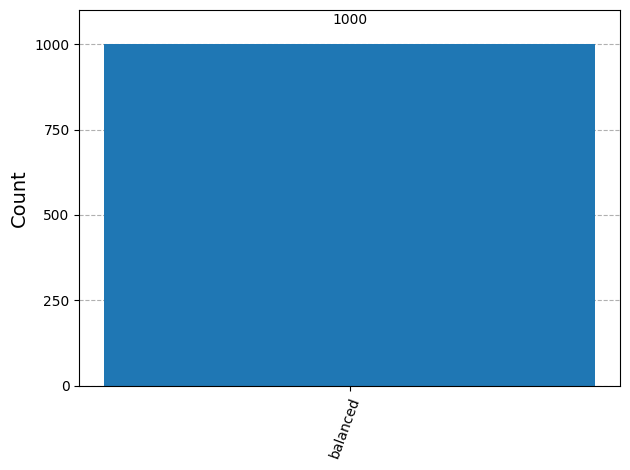

In [ ]:
circ_2 = quantum_circuit(f_2)

circ_2.draw('mpl')

sim = Aer.get_backend('qasm_simulator')
circ_2 = transpile(circ_2, sim)
result = sim.run(circ_2, shots = 1000).result()
counts = result.get_counts(circ_2)
counts_ds2 = dictionary_to_decision(counts)
plot_histogram(counts_ds2)

### $f_3$

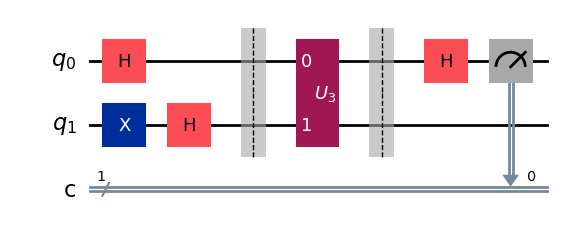

In [ ]:
f_3 = d3.to_gate()
f_3.label = "$U_3$"

circ_3 = quantum_circuit(f_3)

circ_3.draw('mpl')

In [ ]:
# Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circ_3 = pm.run(circ_3)

# Run the job on a real quantum computer

job = sampler.run([circ_3], shots = number_shots)
#job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()
counts_d3 = dictionary_to_decision(counts)

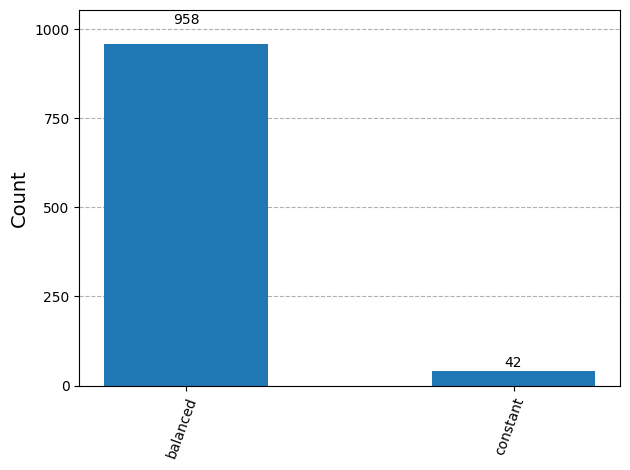

In [ ]:
plot_histogram(counts_d3)

#### $f_3$ in the Aer Simulator

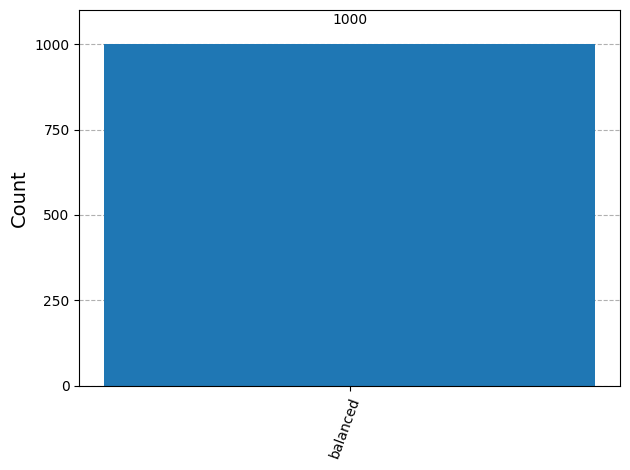

In [ ]:
circ_3 = quantum_circuit(f_3)

circ_3.draw('mpl')

sim = Aer.get_backend('qasm_simulator')
circ_3 = transpile(circ_3, sim)
result = sim.run(circ_3, shots = 1000).result()
counts = result.get_counts(circ_3)
counts_ds3 = dictionary_to_decision(counts)
plot_histogram(counts_ds3)

### $f_4$

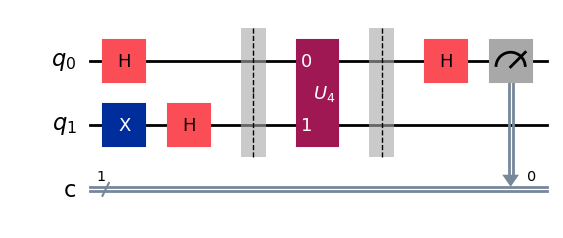

In [ ]:
f_4 = d4.to_gate()
f_4.label = "$U_4$"

circ_4 = quantum_circuit(f_4)

circ_4.draw('mpl')

In [ ]:
# Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circ_4 = pm.run(circ_4)

# Run the job on a real quantum computer

job = sampler.run([circ_4], shots = number_shots)
#job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()
counts_d4 = dictionary_to_decision(counts)

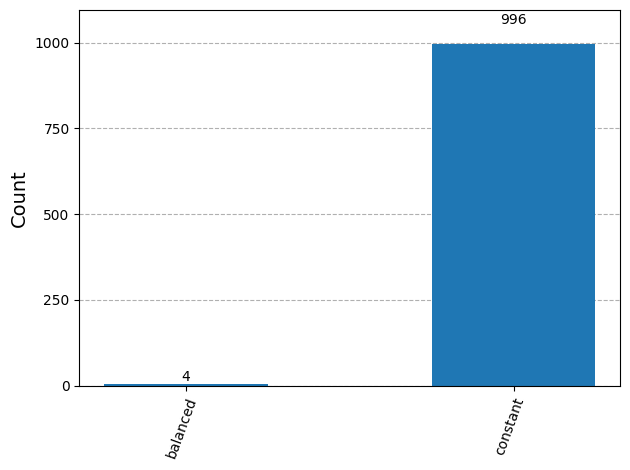

In [ ]:
plot_histogram(counts_d4)

#### $f_4$ in the Aer Simulator

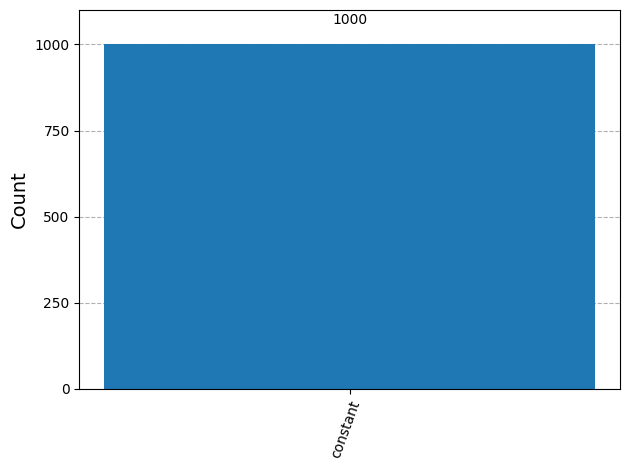

In [ ]:
circ_4 = quantum_circuit(f_4)

circ_4.draw('mpl')

sim = Aer.get_backend('qasm_simulator')
circ_4 = transpile(circ_4, sim)
result = sim.run(circ_4, shots = 1000).result()
counts = result.get_counts(circ_4)
counts_ds4 = dictionary_to_decision(counts)
plot_histogram(counts_ds4)

# Deutsch-Jozsa Algorithm for $n = 2$

The Noise Model we used was based on the `'ibm_fez'` backend service. With this, we test how many times the four types of functions are displayed as constant or balanced. We then average the results of 1000 trials.

### Implementation

In [ ]:
def choose(case: int):
  if case not in list(range(1, 9)):
    raise ValueError('Choose one of the 8 possibilities!')
  if case == 1:
    oracle = dj1
  elif case == 2:
    oracle = dj2
  elif case == 3:
    oracle = dj3
  elif case == 4:
    oracle = dj4
  elif case == 5:
    oracle = dj5
  elif case == 6:
    oracle = dj6
  elif case == 7:
    oracle = dj7
  elif case == 8:
    oracle = dj8
  return oracle

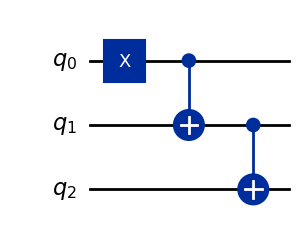

In [ ]:
# Let's make a random implementation to see whether the 'choose' function works

oracle = choose(7)

oracle.draw('mpl')

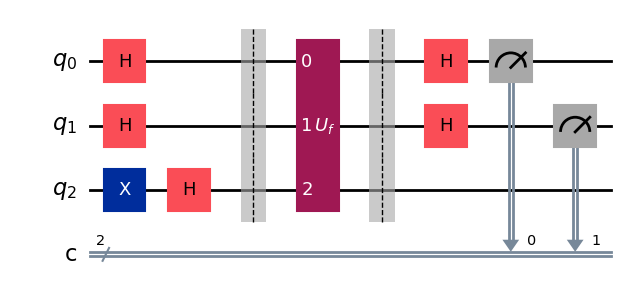

In [ ]:
blackbox = oracle.to_gate()
blackbox.label = '$U_f$'
qc_dj = QuantumCircuit(3, 2)
qc_dj.x(2)
qc_dj.h(range(3))
qc_dj.barrier()
qc_dj.compose(blackbox, inplace = True)
qc_dj.barrier()
qc_dj.h(range(2))
qc_dj.measure(range(2), range(2))

qc_dj.decompose().decompose()

qc_dj.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

As we have a dictionary, and the idea is to test DJ Algorithm many times, we want to make a graph for the constant or balanced function prediction.

In [ ]:
# Implementation of the same dictionary_to_decision function

decision_dj = dictionary_to_decision(counts)

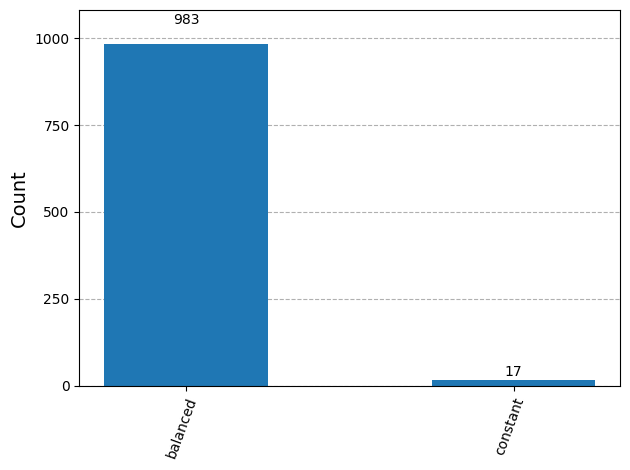

In [ ]:
plot_histogram(decision_dj)

## Trial with 8 possible functions

### $f_1$

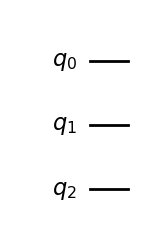

In [ ]:
oracle_1 = choose(1)
display(oracle_1.draw('mpl'))

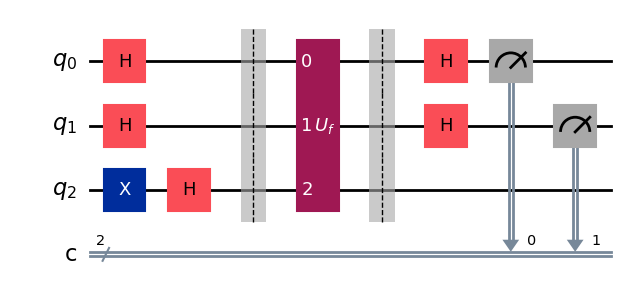

In [ ]:
blackbox = oracle_1.to_gate()
blackbox.label = '$U_f$'
qc_dj1 = QuantumCircuit(3, 2)
qc_dj1.x(2)
qc_dj1.h(range(3))
qc_dj1.barrier()
qc_dj1.compose(blackbox, inplace = True)
qc_dj1.barrier()
qc_dj1.h(range(2))
qc_dj1.measure(range(2), range(2))

qc_dj1.decompose().decompose()

qc_dj1.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj1)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

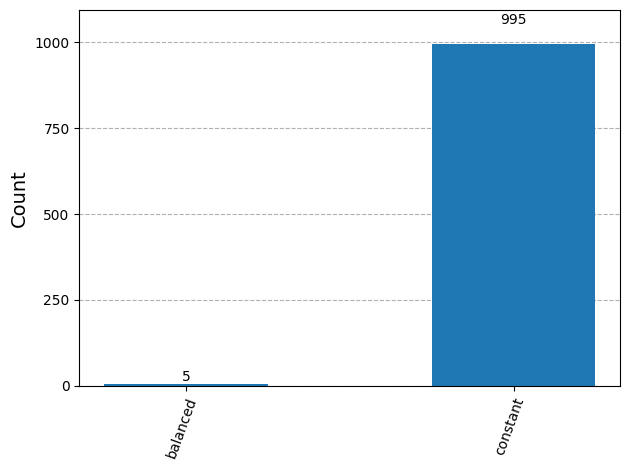

In [ ]:
counts_dj1 = dictionary_to_decision(counts)

plot_histogram(counts_dj1)

#### $f_1$ in the Aer Simulator

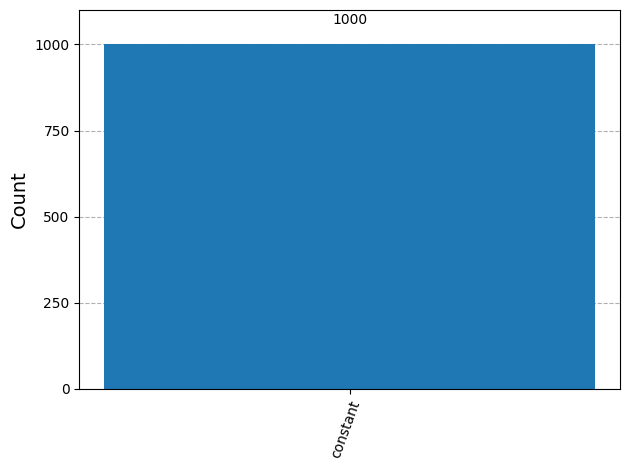

In [ ]:
# Transpile and Execute

sim = Aer.get_backend('qasm_simulator')
circ_1 = transpile(qc_dj1, sim)
result = sim.run(circ_1, shots = 1000).result()
counts = result.get_counts(circ_1)
counts_djs1 = dictionary_to_decision(counts)

plot_histogram(counts_djs1)

### $f_2$

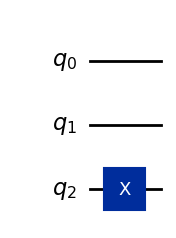

In [ ]:
oracle_2 = choose(2)
display(oracle_2.draw('mpl'))

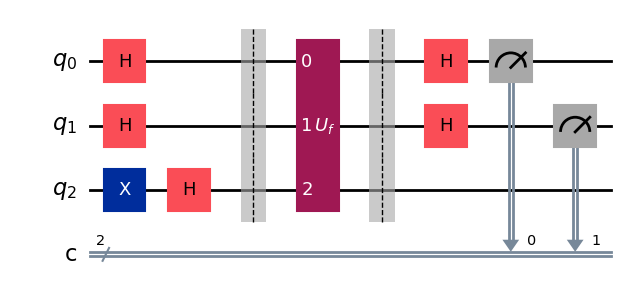

In [ ]:
blackbox = oracle_2.to_gate()
blackbox.label = '$U_f$'
qc_dj2 = QuantumCircuit(3, 2)
qc_dj2.x(2)
qc_dj2.h(range(3))
qc_dj2.barrier()
qc_dj2.compose(blackbox, inplace = True)
qc_dj2.barrier()
qc_dj2.h(range(2))
qc_dj2.measure(range(2), range(2))

qc_dj2.decompose().decompose()

qc_dj2.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj2)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

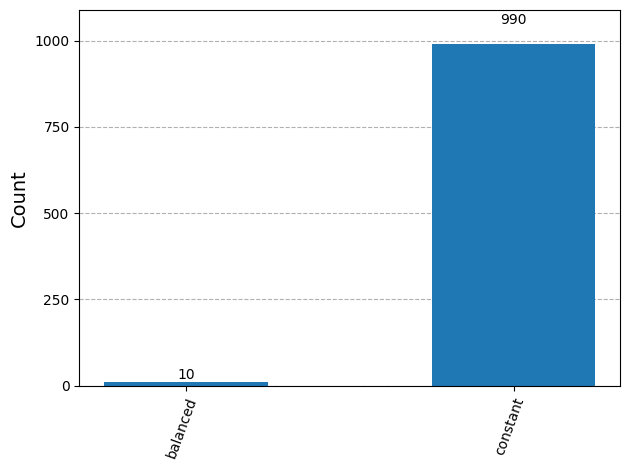

In [ ]:
counts_dj2 = dictionary_to_decision(counts)

plot_histogram(counts_dj2)

#### $f_2$ in the Aer Simulator

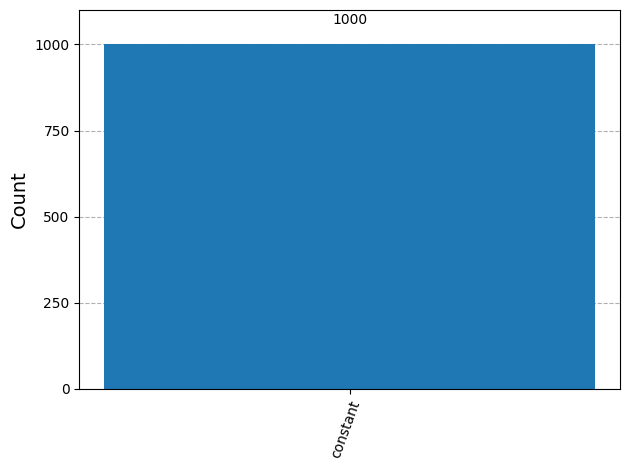

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_2 = transpile(qc_dj2, sim)
result = sim.run(circ_2, shots = 1000).result()
counts = result.get_counts(circ_2)
counts_djs2 = dictionary_to_decision(counts)

plot_histogram(counts_djs2)

### $f_3$

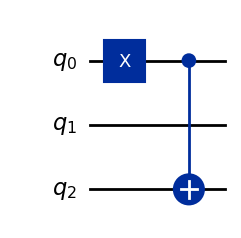

In [ ]:
oracle_3 = choose(3)
display(oracle_3.draw('mpl'))

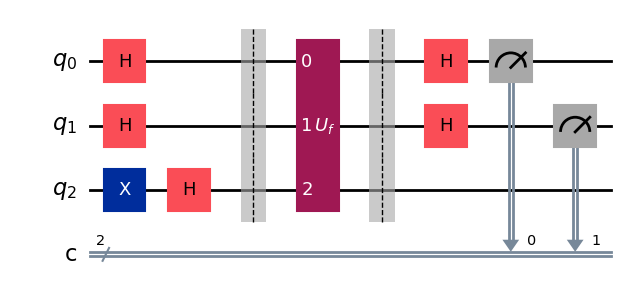

In [ ]:
blackbox = oracle_3.to_gate()
blackbox.label = '$U_f$'
qc_dj3 = QuantumCircuit(3, 2)
qc_dj3.x(2)
qc_dj3.h(range(3))
qc_dj3.barrier()
qc_dj3.compose(blackbox, inplace = True)
qc_dj3.barrier()
qc_dj3.h(range(2))
qc_dj3.measure(range(2), range(2))

qc_dj3.decompose().decompose()

qc_dj3.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj3)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

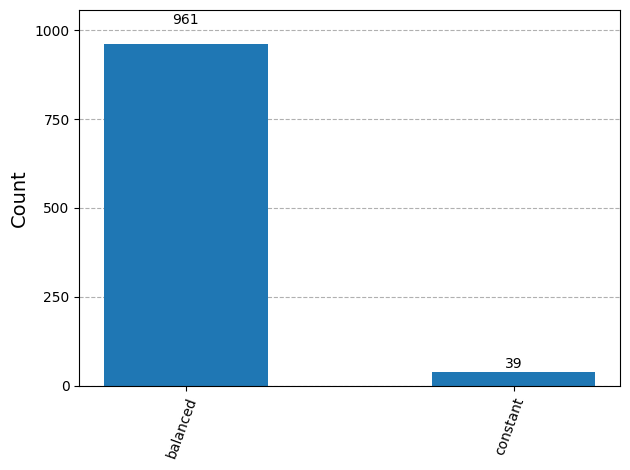

In [ ]:
counts_dj3 = dictionary_to_decision(counts)

plot_histogram(counts_dj3)

#### $f_3$ in the Aer Simulator

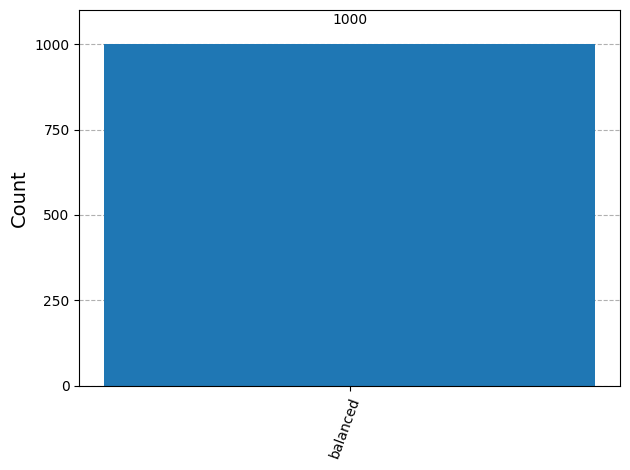

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_3 = transpile(qc_dj3, sim)
result = sim.run(circ_3, shots = 1000).result()
counts = result.get_counts(circ_3)
counts_djs3 = dictionary_to_decision(counts)

plot_histogram(counts_djs3)

### $f_4$

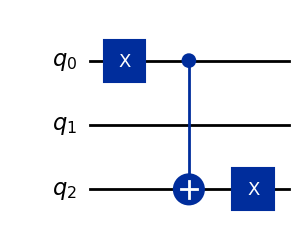

In [ ]:
oracle_4 = choose(4)
display(oracle_4.draw('mpl'))

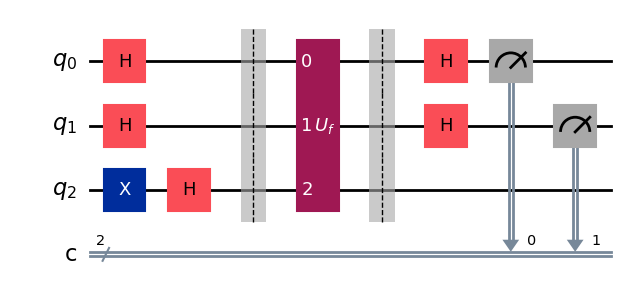

In [ ]:
blackbox = oracle_4.to_gate()
blackbox.label = '$U_f$'
qc_dj4 = QuantumCircuit(3, 2)
qc_dj4.x(2)
qc_dj4.h(range(3))
qc_dj4.barrier()
qc_dj4.compose(blackbox, inplace = True)
qc_dj4.barrier()
qc_dj4.h(range(2))
qc_dj4.measure(range(2), range(2))

qc_dj4.decompose().decompose()

qc_dj4.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj4)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

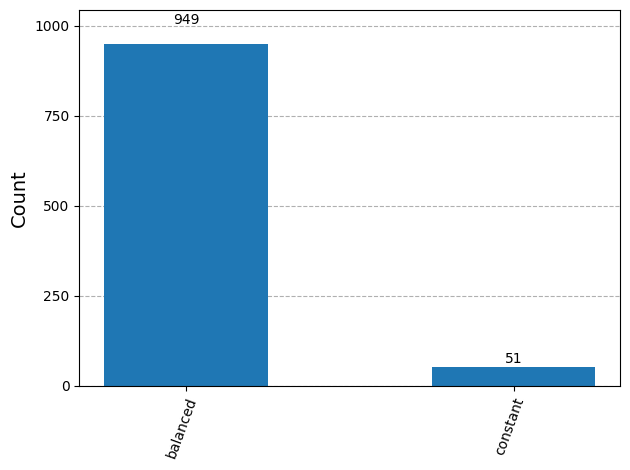

In [ ]:
counts_dj4 = dictionary_to_decision(counts)

plot_histogram(counts_dj4)

#### $f_4$ in the Aer Simulator

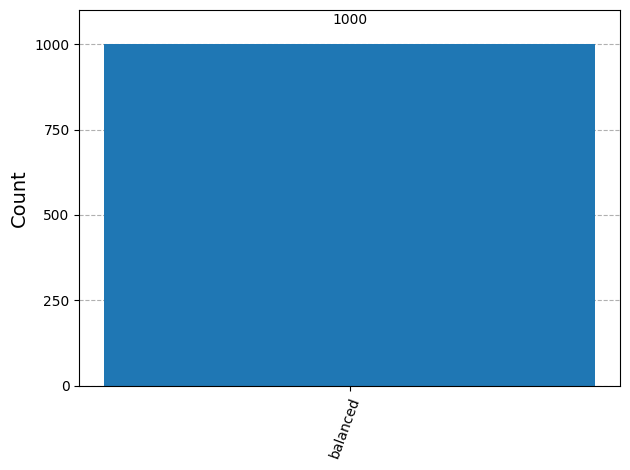

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_4 = transpile(qc_dj4, sim)
result = sim.run(circ_4, shots = 1000).result()
counts = result.get_counts(circ_4)
counts_djs4 = dictionary_to_decision(counts)

plot_histogram(counts_djs4)

### $f_5$

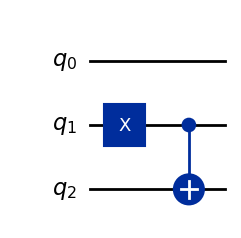

In [ ]:
oracle_5 = choose(5)
display(oracle_5.draw('mpl'))

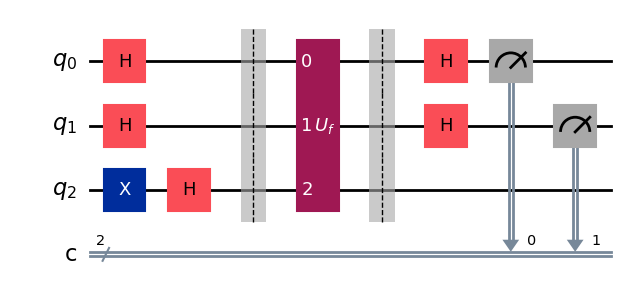

In [ ]:
blackbox = oracle_5.to_gate()
blackbox.label = '$U_f$'
qc_dj5 = QuantumCircuit(3, 2)
qc_dj5.x(2)
qc_dj5.h(range(3))
qc_dj5.barrier()
qc_dj5.compose(blackbox, inplace = True)
qc_dj5.barrier()
qc_dj5.h(range(2))
qc_dj5.measure(range(2), range(2))

qc_dj5.decompose().decompose()

qc_dj5.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj5)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

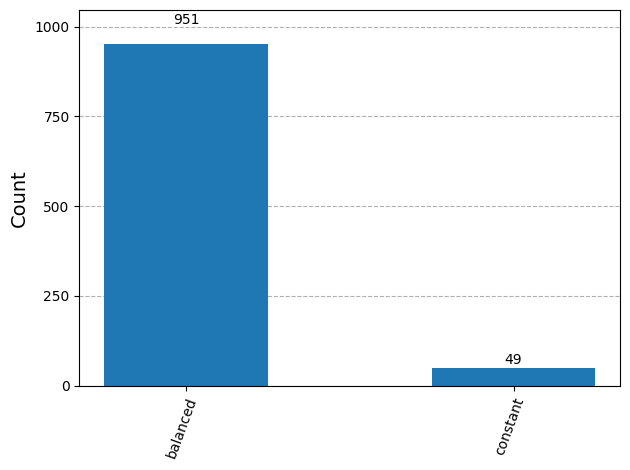

In [ ]:
counts_dj5 = dictionary_to_decision(counts)

plot_histogram(counts_dj5)

#### $f_5$ in the Aer Simulator

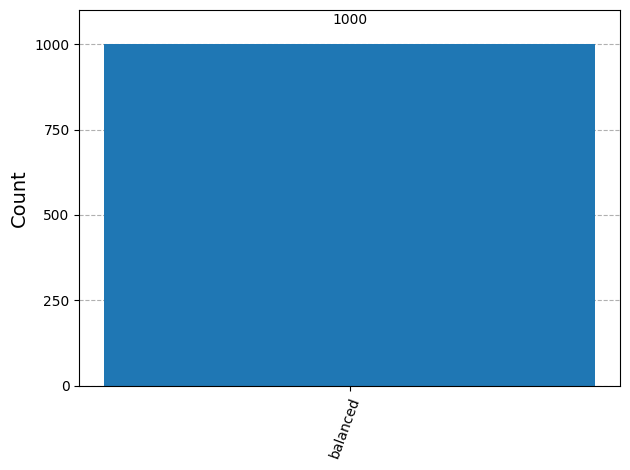

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_5 = transpile(qc_dj5, sim)
result = sim.run(circ_5, shots = 1000).result()
counts = result.get_counts(circ_5)
counts_djs5 = dictionary_to_decision(counts)

plot_histogram(counts_djs5)

### $f_6$

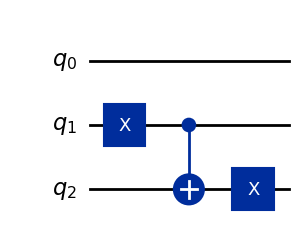

In [ ]:
oracle_6 = choose(6)
display(oracle_6.draw('mpl'))

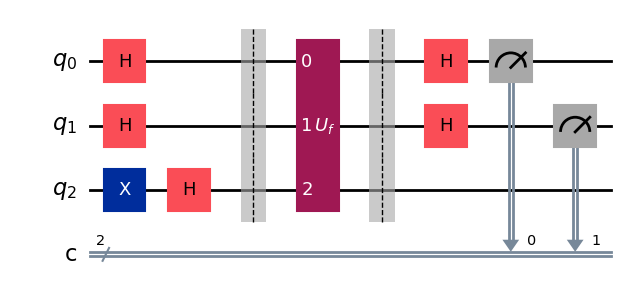

In [ ]:
blackbox = oracle_6.to_gate()
blackbox.label = '$U_f$'
qc_dj6 = QuantumCircuit(3, 2)
qc_dj6.x(2)
qc_dj6.h(range(3))
qc_dj6.barrier()
qc_dj6.compose(blackbox, inplace = True)
qc_dj6.barrier()
qc_dj6.h(range(2))
qc_dj6.measure(range(2), range(2))

qc_dj6.decompose().decompose()

qc_dj6.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj6)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

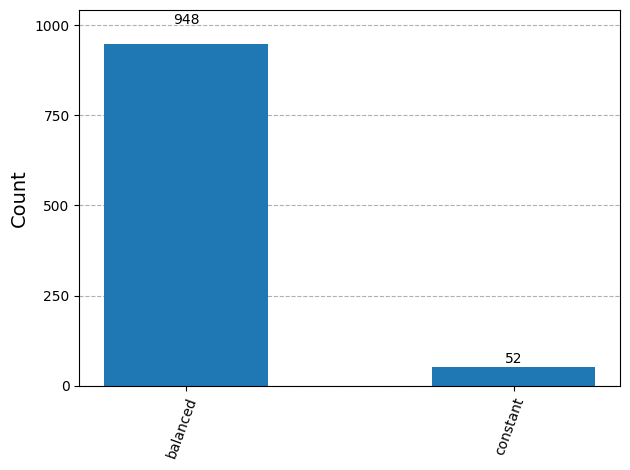

In [ ]:
counts_dj6 = dictionary_to_decision(counts)

plot_histogram(counts_dj6)

#### $f_6$ in the Aer Simulator

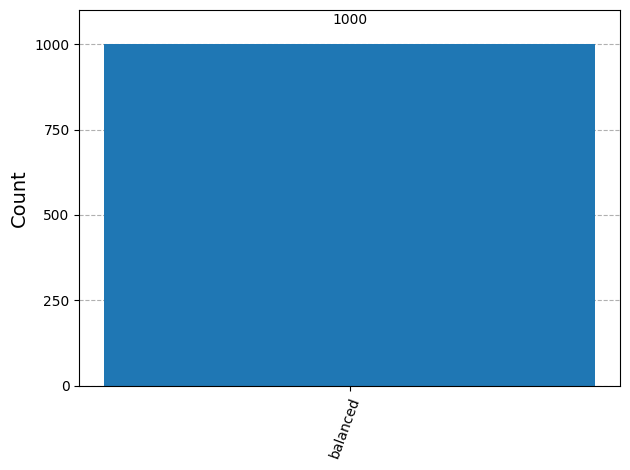

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_6 = transpile(qc_dj6, sim)
result = sim.run(circ_6, shots = 1000).result()
counts = result.get_counts(circ_6)
counts_djs6 = dictionary_to_decision(counts)

plot_histogram(counts_djs6)

### $f_7$

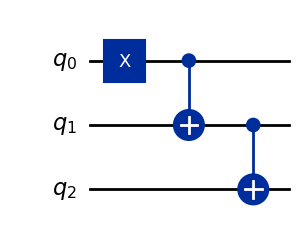

In [ ]:
oracle_7 = choose(7)
display(oracle_7.draw('mpl'))

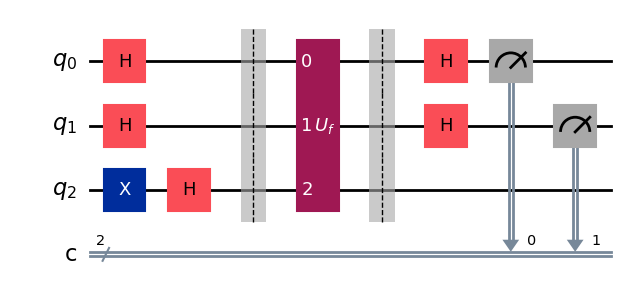

In [ ]:
blackbox = oracle_7.to_gate()
blackbox.label = '$U_f$'
qc_dj7 = QuantumCircuit(3, 2)
qc_dj7.x(2)
qc_dj7.h(range(3))
qc_dj7.barrier()
qc_dj7.compose(blackbox, inplace = True)
qc_dj7.barrier()
qc_dj7.h(range(2))
qc_dj7.measure(range(2), range(2))

qc_dj7.decompose().decompose()

qc_dj7.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj7)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

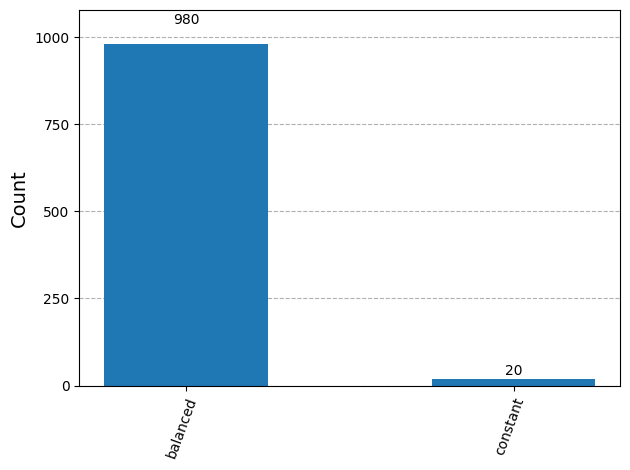

In [ ]:
counts_dj7 = dictionary_to_decision(counts)

plot_histogram(counts_dj7)

#### $f_7$ in the Aer Simulator

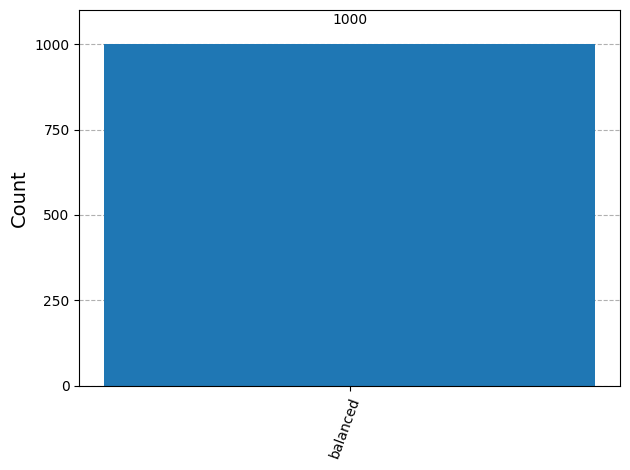

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_7 = transpile(qc_dj7, sim)
result = sim.run(circ_7, shots = 1000).result()
counts = result.get_counts(circ_7)
counts_djs7 = dictionary_to_decision(counts)

plot_histogram(counts_djs7)

### $f_8$

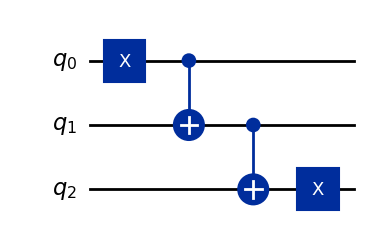

In [ ]:
oracle_8 = choose(8)
display(oracle_8.draw('mpl'))

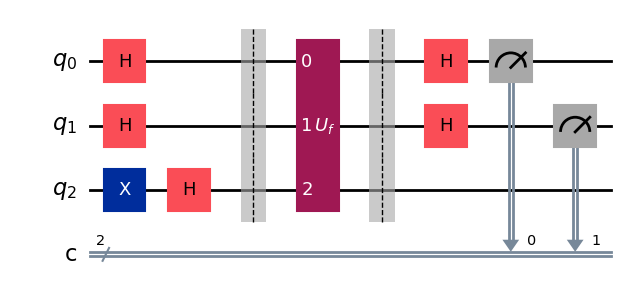

In [ ]:
blackbox = oracle_8.to_gate()
blackbox.label = '$U_f$'
qc_dj8 = QuantumCircuit(3, 2)
qc_dj8.x(2)
qc_dj8.h(range(3))
qc_dj8.barrier()
qc_dj8.compose(blackbox, inplace = True)
qc_dj8.barrier()
qc_dj8.h(range(2))
qc_dj8.measure(range(2), range(2))

qc_dj8.decompose().decompose()

qc_dj8.draw('mpl')

In [ ]:
# Transpile

target = backend.target

pm = generate_preset_pass_manager(target = target, optimization_level = 3)

qc_isa = pm.run(qc_dj8)

In [ ]:
# Run the job on a quantum computer

job = sampler.run([qc_isa], shots = 1000)

res = job.result()

counts = res[0].data.c.get_counts()

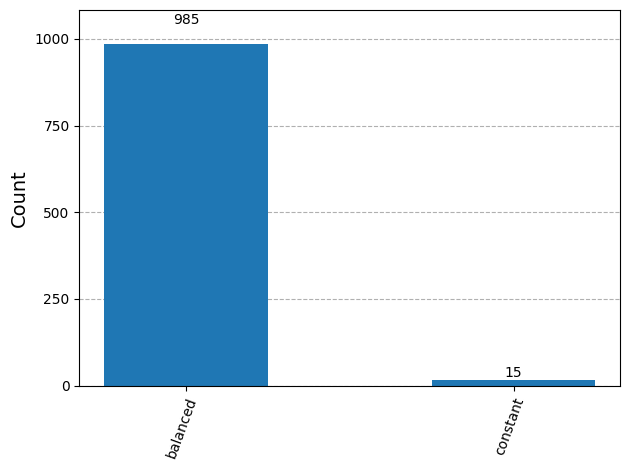

In [ ]:
counts_dj8 = dictionary_to_decision(counts)

plot_histogram(counts_dj8)

#### $f_8$ in the Aer Simulator

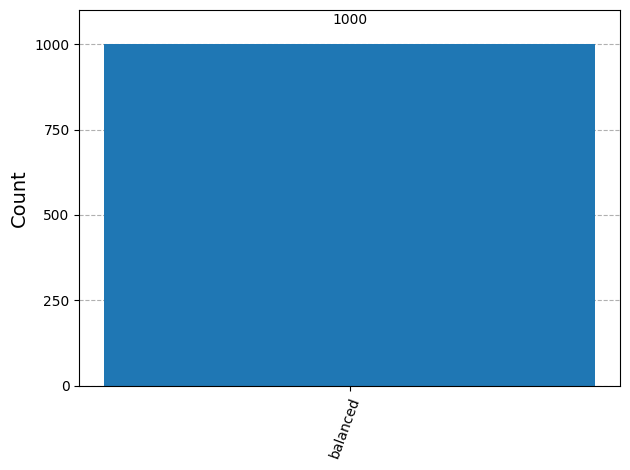

In [ ]:
# Transpile, Execute and Show

sim = Aer.get_backend('qasm_simulator')
circ_8 = transpile(qc_dj8, sim)
result = sim.run(circ_8, shots = 1000).result()
counts = result.get_counts(circ_8)
counts_djs8 = dictionary_to_decision(counts)

plot_histogram(counts_djs8)

# Results

Here we'll show the main graphs considering all the executions within the `'ibm_marrakesh'` backend.


## Deutsch Algorithm

### All functions

The main results of the implementation of the four oracles compared to the supposedly **exact** Aer Simulator are shown below.

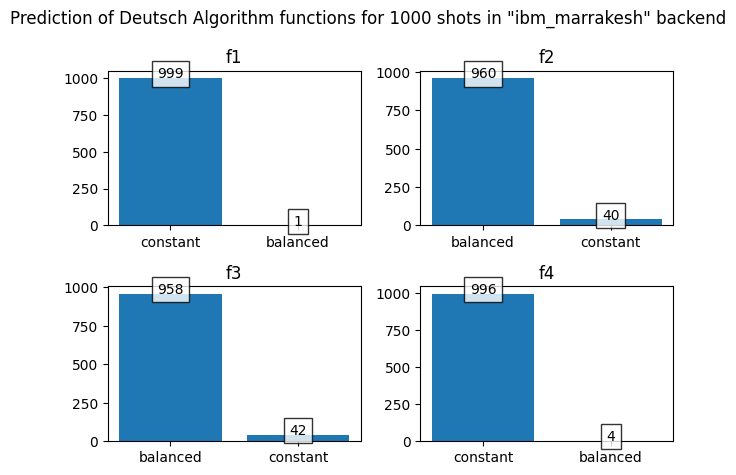

In [ ]:
def text_values(ax, counter):
  for i in counter.keys():
    ax.text(i, counter[i], counter[i], ha = 'center', bbox = dict(facecolor = 'white', alpha = 0.8))

fig, axs = plt.subplots(2, 2)
fig.suptitle('Prediction of Deutsch Algorithm functions for 1000 shots in "ibm_marrakesh" backend')
axs[0, 0].bar(counts_d1.keys(), counts_d1.values())
axs[0,0].set_title('f1')
text_values(axs[0,0], counts_d1)
axs[0, 1].bar(counts_d2.keys(), counts_d2.values())
axs[0,1].set_title('f2')
text_values(axs[0,1], counts_d2)
axs[1, 0].bar(counts_d3.keys(), counts_d3.values())
axs[1,0].set_title('f3')
text_values(axs[1,0], counts_d3)
axs[1, 1].bar(counts_d4.keys(), counts_d4.values())
axs[1,1].set_title('f4')
text_values(axs[1,1], counts_d4)

fig.tight_layout()

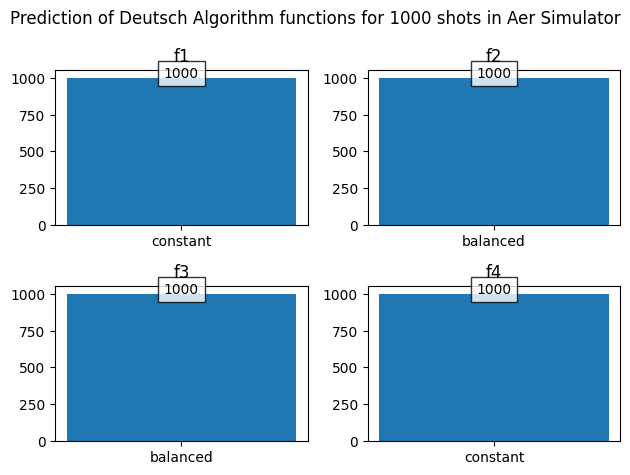

In [ ]:
fig, axs = plt.subplots(2, 2)
fig.suptitle('Prediction of Deutsch Algorithm functions for 1000 shots in Aer Simulator')
axs[0, 0].bar(counts_ds1.keys(), counts_ds1.values())
axs[0,0].set_title('f1')
text_values(axs[0,0], counts_ds1)
axs[0, 1].bar(counts_ds2.keys(), counts_ds2.values())
axs[0,1].set_title('f2')
text_values(axs[0,1], counts_ds2)
axs[1, 0].bar(counts_ds3.keys(), counts_ds3.values())
axs[1,0].set_title('f3')
text_values(axs[1,0], counts_ds3)
axs[1, 1].bar(counts_ds4.keys(), counts_ds4.values())
axs[1,1].set_title('f4')
text_values(axs[1,1], counts_ds4)

fig.tight_layout()

### Constant vs. Balanced

Knowing that $f_1$ and $f_4$ are the *constant* functions, we proceed to make averages and compare the performances of the two type of functions.

Real QC

In [ ]:
# Prediction of constant's

balanced_cd = counts_d1['balanced'] + counts_d4['balanced'] # Prediction of balanced for a constant function
constant_cd = counts_d1['constant'] + counts_d4['constant'] # Prediction of constant for a constant function

# Prediction of balanced's

balanced_bd = counts_d2['balanced'] + counts_d3['balanced'] # Prediction of balanced for a balanced function
constant_bd = counts_d2['constant'] + counts_d3['constant'] # Prediction of constant for a balanced function

print(f'For constant functions, Deutsch Algorithm predicted correctly, in average, in {constant_cd/2} shots. \n')
print(f'For balanced functions, Deutsch Algorithm predicted correctly, in average, in {balanced_bd/2} shots.')

For constant functions, Deutsch Algorithm predicted correctly, in average, in 997.5 shots. 

For balanced functions, Deutsch Algorithm predicted correctly, in average, in 959.0 shots.


Aer Simulator

In [ ]:
# Prediction of constant's

balanced_cds = counts_ds1['balanced'] + counts_ds4['balanced'] # Prediction of balanced for a constant function
constant_cds = counts_ds1['constant'] + counts_ds4['constant'] # Prediction of constant for a constant function

# Prediction of balanced's

balanced_bds = counts_ds2['balanced'] + counts_ds3['balanced'] # Prediction of balanced for a balanced function
constant_bds = counts_ds2['constant'] + counts_ds3['constant'] # Prediction of constant for a balanced function

print(f'For constant functions, Deutsch Algorithm predicted correctly, in average, in {constant_cds/2} shots. \n')
print(f'For balanced functions, Deutsch Algorithm predicted correctly, in average, in {balanced_bds/2} shots.')

For constant functions, Deutsch Algorithm predicted correctly, in average, in 1000.0 shots. 

For balanced functions, Deutsch Algorithm predicted correctly, in average, in 1000.0 shots.


In this project, we're going to treat uniquely **accuracies**, which is the ratio of correct answers to the total number of trials.

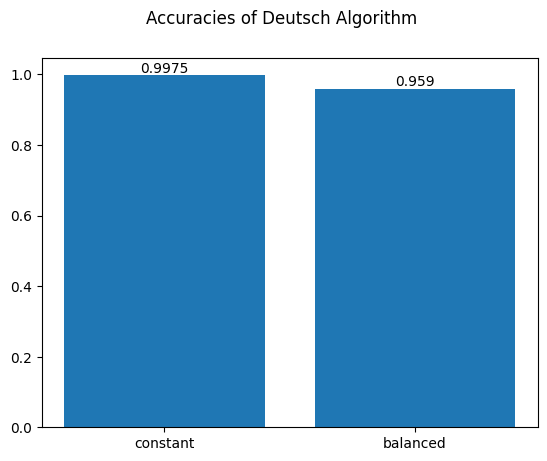

In [ ]:
# Accuracies

constant_accd = constant_cd/constant_cds # Averaging accuracies with no ponderation

balanced_accd = balanced_bd/balanced_bds

category = ['constant', 'balanced']
accuracies_d = [constant_accd, balanced_accd]

fig, ax = plt.subplots()
bar_container_d = ax.bar(category, accuracies_d)
ax.bar_label(bar_container_d)
fig.suptitle('Accuracies of Deutsch Algorithm')
plt.show()

## Deutsch-Jozsa Algorithm

### All functions

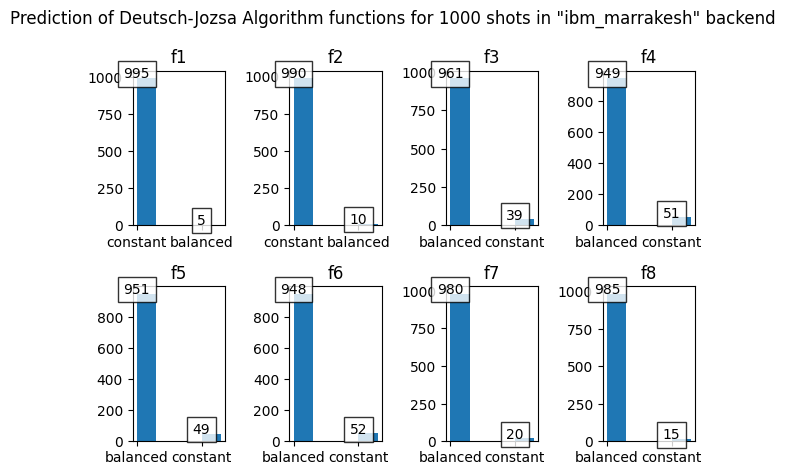

In [ ]:
fig, axs = plt.subplots(2, 4)
fig.suptitle('Prediction of Deutsch-Jozsa Algorithm functions for 1000 shots in "ibm_marrakesh" backend')

axs[0, 0].bar(counts_dj1.keys(), counts_dj1.values(), align = 'edge', width = 0.3)
axs[0,0].set_title('f1')
text_values(axs[0,0], counts_dj1)
axs[0, 1].bar(counts_dj2.keys(), counts_dj2.values(), align = 'edge', width = 0.3)
axs[0, 1].set_title('f2')
text_values(axs[0,1], counts_dj2)
axs[0, 2].bar(counts_dj3.keys(), counts_dj3.values(), align = 'edge', width = 0.3)
axs[0, 2].set_title('f3')
text_values(axs[0, 2], counts_dj3)
axs[0, 3].bar(counts_dj4.keys(), counts_dj4.values(), align = 'edge', width = 0.3)
axs[0, 3].set_title('f4')
text_values(axs[0, 3], counts_dj4)
axs[1, 0].bar(counts_dj5.keys(), counts_dj5.values(), align = 'edge', width = 0.3)
axs[1,0].set_title('f5')
text_values(axs[1,0], counts_dj5)
axs[1, 1].bar(counts_dj6.keys(), counts_dj6.values(), align = 'edge', width = 0.3)
axs[1, 1].set_title('f6')
text_values(axs[1,1], counts_dj6)
axs[1, 2].bar(counts_dj7.keys(), counts_dj7.values(), align = 'edge', width = 0.3)
axs[1, 2].set_title('f7')
text_values(axs[1, 2], counts_dj7)
axs[1, 3].bar(counts_dj8.keys(), counts_dj8.values(), align = 'edge', width = 0.3)
axs[1, 3].set_title('f8')
text_values(axs[1, 3], counts_dj8)

fig.tight_layout()

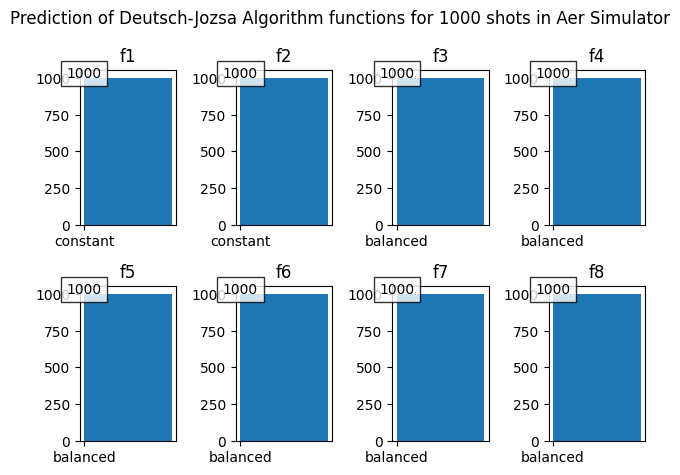

In [ ]:
fig, axs = plt.subplots(2, 4)
fig.suptitle('Prediction of Deutsch-Jozsa Algorithm functions for 1000 shots in Aer Simulator')

axs[0, 0].bar(counts_djs1.keys(), counts_djs1.values(), align = 'edge', width = 0.3)
axs[0,0].set_title('f1')
text_values(axs[0,0], counts_djs1)
axs[0, 1].bar(counts_djs2.keys(), counts_djs2.values(), align = 'edge', width = 0.3)
axs[0, 1].set_title('f2')
text_values(axs[0,1], counts_djs2)
axs[0, 2].bar(counts_djs3.keys(), counts_djs3.values(), align = 'edge', width = 0.3)
axs[0, 2].set_title('f3')
text_values(axs[0, 2], counts_djs3)
axs[0, 3].bar(counts_djs4.keys(), counts_djs4.values(), align = 'edge', width = 0.3)
axs[0, 3].set_title('f4')
text_values(axs[0, 3], counts_djs4)
axs[1, 0].bar(counts_djs5.keys(), counts_djs5.values(), align = 'edge', width = 0.3)
axs[1,0].set_title('f5')
text_values(axs[1,0], counts_djs5)
axs[1, 1].bar(counts_djs6.keys(), counts_djs6.values(), align = 'edge', width = 0.3)
axs[1, 1].set_title('f6')
text_values(axs[1,1], counts_djs6)
axs[1, 2].bar(counts_djs7.keys(), counts_djs7.values(), align = 'edge', width = 0.3)
axs[1, 2].set_title('f7')
text_values(axs[1, 2], counts_djs7)
axs[1, 3].bar(counts_djs8.keys(), counts_djs8.values(), align = 'edge', width = 0.3)
axs[1, 3].set_title('f8')
text_values(axs[1, 3], counts_djs8)

fig.tight_layout()

### Constant vs. Balanced

Knowing that $f_1$ and $f_2$ are the *constant* functions, we proceed to make averages and compare the performances of the two type of functions.

Real QC

In [ ]:
# Prediction of constant's

balanced_cdj = counts_dj1['balanced'] + counts_dj2['balanced'] # Prediction of balanced for a constant function
constant_cdj = counts_dj1['constant'] + counts_dj2['constant'] # Prediction of constant for a constant function

# Prediction of balanced's

balanced_bdj = counts_dj3['balanced'] + counts_dj4['balanced'] + counts_dj5['balanced'] + counts_dj6['balanced'] + counts_dj7['balanced'] + counts_dj8['balanced'] # Prediction of balanced for a balanced function
constant_bdj = counts_dj3['constant'] + counts_dj4['constant'] + counts_dj5['constant'] +counts_dj6['constant'] + counts_dj7['constant'] + counts_dj8['constant'] # Prediction of constant for a balanced function

print(f'For constant functions, Deutsch Algorithm predicted correctly, in average, in {constant_cdj/2} shots. \n')
print(f'For balanced functions, Deutsch Algorithm predicted correctly, in average, in {balanced_bdj/6} shots.')

For constant functions, Deutsch Algorithm predicted correctly, in average, in 992.5 shots. 

For balanced functions, Deutsch Algorithm predicted correctly, in average, in 962.3333333333334 shots.


Aer Simulator

In [ ]:
# Prediction of constant's

balanced_cdjs = counts_djs1['balanced'] + counts_djs2['balanced'] # Prediction of balanced for a constant function
constant_cdjs = counts_djs1['constant'] + counts_djs2['constant'] # Prediction of constant for a constant function

# Prediction of balanced's

balanced_bdjs = counts_djs3['balanced'] + counts_djs4['balanced'] + counts_djs5['balanced'] + counts_djs6['balanced'] + counts_djs7['balanced'] + counts_djs8['balanced'] # Prediction of balanced for a balanced function
constant_bdjs = counts_djs3['constant'] + counts_djs4['constant'] + counts_djs5['constant'] + counts_djs6['constant'] + counts_djs7['constant'] + counts_djs8['constant'] # Prediction of constant for a balanced function

print(f'For constant functions, Deutsch Algorithm predicted correctly, in average, in {constant_cdjs/2} shots. \n')
print(f'For balanced functions, Deutsch Algorithm predicted correctly, in average, in {balanced_bdjs/6} shots.')

For constant functions, Deutsch Algorithm predicted correctly, in average, in 1000.0 shots. 

For balanced functions, Deutsch Algorithm predicted correctly, in average, in 1000.0 shots.


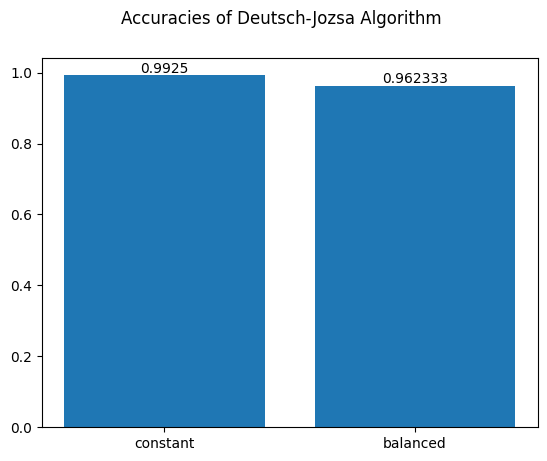

In [ ]:
# Accuracies

constant_accdj = constant_cdj/constant_cdjs # Averaging accuracies with no ponderation

balanced_accdj = balanced_bdj/balanced_bdjs

category = ['constant', 'balanced']
accuracies_dj = [constant_accdj, balanced_accdj]

fig, ax = plt.subplots()
bar_container = ax.bar(category, accuracies_dj)
ax.bar_label(bar_container)
fig.suptitle('Accuracies of Deutsch-Jozsa Algorithm')
plt.show()

## Table of Accuracies

This table shows the accuracies for the Deutsch and Deutsch-Jozsa Algorithm prediction for constant and balanced functions.

In [ ]:
data = {
    'Algorithm' : ['Deutsch', 'Deutsch-Jozsa'],
    'Constant' : [constant_accd * 100, constant_accdj * 100],
    'Balanced' : [balanced_accd * 100, balanced_accdj * 100]
}

table = pd.DataFrame(data)
table.style.set_caption('Accuracies in the Algorithms in "ibm_marrakesh" backend')
table.set_index('Algorithm', inplace = True)
table

,Constant,Balanced
Algorithm,,
Deutsch,99.75,95.900000
Deutsch-Jozsa,99.25,96.233333


# Conclusions

## Main Points




*   Deutsch and Deutsch-Jozsa Algorithms work on guessing the function at a high number of trials.
*   A real Quantum Computer may still need more than one query in guessing the function.
*   Balanced function prediction is less accurate than constant function prediction.



## Interpretations

As Quantum Computers are still in a really early stage of development, noise may affect algorithm's response unexpectedly, giving the fact that maybe a single query cannot be enough implementing Deutsch and Deutsch-Jozsa Algorithms.

However, in a big number of trials, the algorithms tend to guess correctly by more than 90% of the chances, giving high fidelity to Deutsch and Deutsch-Jozsa Algorithm when executed in a high number of shots.

Regarding the finding that **balanced function prediction is less accurate than constant function prediction**, it is seen as a rare event, since the algorithm is the same for both category of functions.

A possible explanation for this behavior is that, as the oracle execution is also part of the real Quantum Computer, and balanced oracle functions involve a two-qubit gate which is more prone to errors, then the great part of noise effect may be caused by the oracle itself and not by the rest of the Quantum Circuit.

## Future Work

Potential future work that can stand upon this project involves creating a "more perfect" oracle based on *Error Correction*, so we test **only** the Deutsch and Deutsch-Jozsa Algorithms efficiency. Also, implementing the Deutsch-Jozsa algorithm for the function $f: \{0,1\}^n \rightarrow \{0,1\}$ with a  $n > 2$ may serve to see whether there is a tendency in the prediction accuracy of the Deutsch-Jozsa Algorithm.

In an additional case, to prevent a high number of shots, a potential new research could be done on testing the minimum number of required shots so the Algorithm (either Deutsch or Deutsch-Jozsa) can have an accuracy higher than 90%.

The potential new projects from this one are numerous, with a complete new range of opportunities of improvement.

# References

1. Weathers, Jeremy M. (2010). *Methods for quantum circuit design and simulation*. *Calhoun: The NPS Institutional Archive DSpace Repository*.

2. Cleve, Richard, Ekert, Artur, Macchiavello, Chiara, & Mosca, Michele (1998). *Quantum Algorithms Revisited*. *Proceedings of The Royal Society A: Mathematical, Physical and Engineering Sciences*. https://doi.org/10.1098/rspa.1998.0164

3. Jaradat, Yousef, Alia, Mohammad, Masoud, M., Mansrah, Ahmad, Jannoud, Ismael, & Alheyasat, Omar (2023). *Roadmap for Simulating Quantum Circuits Utilising IBM’s Qiskit Library: Programming Approach*. *The Eurasia Proceedings of Science, Technology, Engineering & Mathematics*. https://doi.org/10.55549/epstem.1412445

4. Deutsch, D. (1985). *Quantum theory, the Church–Turing principle and the universal quantum computer*. *Proceedings of the Royal Society of London. A. Mathematical and Physical Sciences*. https://doi.org/10.1098/rspa.1985.0070

5. Deutsch, D., & Jozsa, R. (1992). *Rapid solution of problems by quantum computation*. *Proceedings of the Royal Society of London. Series A: Mathematical and Physical Sciences*. https://doi.org/10.1098/rspa.1992.0167

6. Kothari, K., & Chaudhuri, P. R. (2025). *Qubit Manipulation in Quantum Circuits - Solving Grover's Algorithm for 2- and 3-Qubit Systems*. *Beyond Quantum Proceedings 2025*.

7. Youvan, Douglas (2023). *Quantum Oracles: Design, Implementation, and Implications in Quantum Search
Algorithms*. https://doi.org/10.13140/RG.2.2.27075.78884

8. Nakahara, Mikio, & Ohmi, Tetsuo (2008). *Quantum Computing - From Linear Algebra to Physical Realizations*. https://doi.org/10.1201/9781420012293

9. Nielsen, Michael A., & Chuang, Isaac L. (2010). *Quantum Computation and Quantum Information: 10th Anniversary Edition*. Cambridge University Press.

10. Qiskit Textbook. *Learn Quantum Computation using Qiskit*. https://qiskit.org/learn

11. Javadi-Abhari, Ali, Treinish, Matthew, Krsulich, Kevin, Wood, Christopher J., Lishman, Jake, Gacon, Julien, Martiel, Simon, Nation, Paul D., Bishop, Lev S., Cross, Andrew W., Johnson, Blake R., & Gambetta, Jay M. (2024). *Quantum computing with Qiskit*. arXiv:2405.08810. https://arxiv.org/abs/2405.08810

12. *Noise Analysis of Grover's Quantum Search Algorithm* (2023). *Indian Journal of Pure & Applied Physics*. https://doi.org/10.56042/ijpap.v61i5.69090

